In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [4]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt

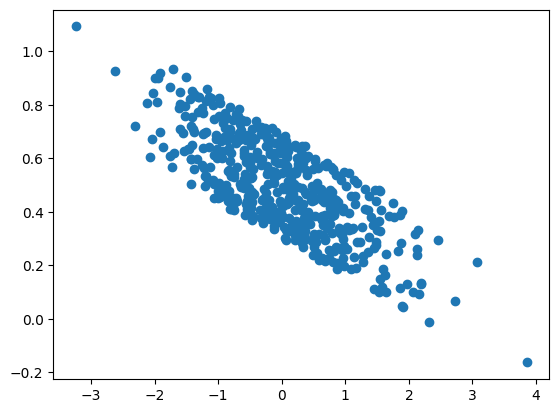

In [4]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [ ]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


20. Training loss: 0.24936302539177843, Val loss:0.23779367775290097
40. Training loss: 0.12311745551907949, Val loss:0.11681806641746481
60. Training loss: 0.06443422445965458, Val loss:0.06072159682449449
80. Training loss: 0.03714993488798042, Val loss:0.03474088572672316
100. Training loss: 0.024461533163063473, Val loss:0.022730598385935285
120. Training loss: 0.01855963209586907, Val loss:0.01719436666565953
140. Training loss: 0.01581386954755161, Val loss:0.014653424498595547
160. Training loss: 0.01453620866671972, Val loss:0.013494844785490758
180. Training loss: 0.013941580450135277, Val loss:0.012971844001942814
200. Training loss: 0.013664791563666538, Val loss:0.012739408114859366
220. Training loss: 0.013535930676304583, Val loss:0.012638662146203222
240. Training loss: 0.013475929575006195, Val loss:0.01259680736884065
260. Training loss: 0.013447987449436751, Val loss:0.012580735897348023
280. Training loss: 0.013434973221060457, Val loss:0.01257556311162023
300. Train

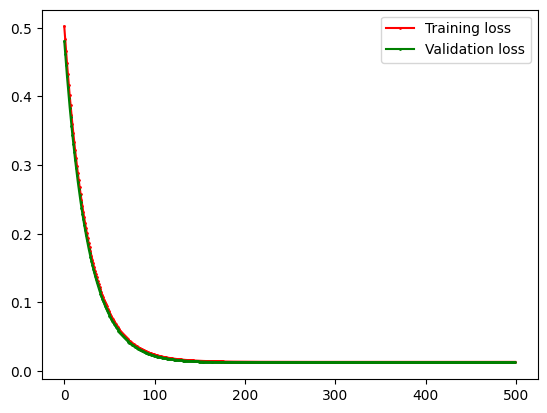

In [ ]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [12]:
# Get the Prediction
y_val_pred = model.predict(X_val)

In [ ]:
# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

=== Linear Regression Evaluation ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


{'MSE': 0.013355229539356039,
 'MAE': 0.10095149880498926,
 'RMSE': np.float64(0.11556482829717717),
 'R-squared': 0.5689997481843656}

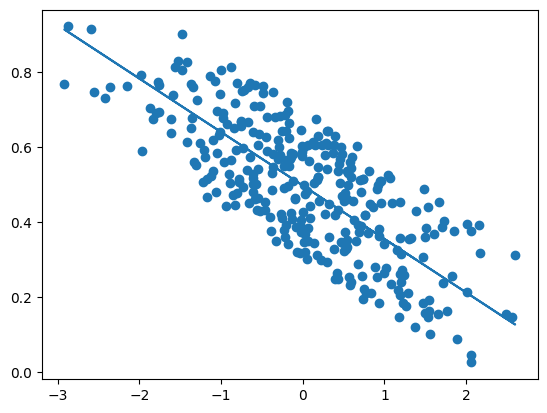

In [ ]:
# Plot
plt.scatter(X_val[:,1],y_val)
plt.plot(X_val[:,1],y_val_pred)
plt.show()